# Visualização Executiva dos Mercados Brasileiros

## Objetivo

Apresentar visualmente os resultados obtidos nas etapas de modelagem e clusterização dos municípios brasileiros.

## Contexto

Após a construção dos indicadores econômicos e demográficos e da segmentação dos municípios por Machine Learning, esta etapa tem como objetivo facilitar a interpretação dos resultados e apoiar a tomada de decisão.

## Visualizações Desenvolvidas

- Distribuição dos municípios por cluster
- Comparação dos indicadores médios entre clusters
- Ranking dos municípios com maior potencial de consumo

## Aplicação

As visualizações permitem identificar padrões de mercado, oportunidades regionais e perfis econômicos distintos para apoiar análises de Inteligência de Mercado, Marketing e Expansão Comercial.

In [6]:
# — Carregamento da Base Final ──────────────────────────────────
# COMO funciona: carrega a base utilizada na clusterização refinada.
# ONDE é usado: fonte de dados para as visualizações executivas.
# POR QUE esta escolha: centralizar todas as análises em uma única base.
# QUANDO rodar: início do notebook.
# O QUE produz: DataFrame pronto para geração dos gráficos.

import pandas as pd

df_municipios = pd.read_csv(
    "dados/processados/base_municipios_clusterizada.csv",
    encoding="utf-8-sig"
)

print("Dimensões:")
print(df_municipios.shape)

Dimensões:
(5570, 17)


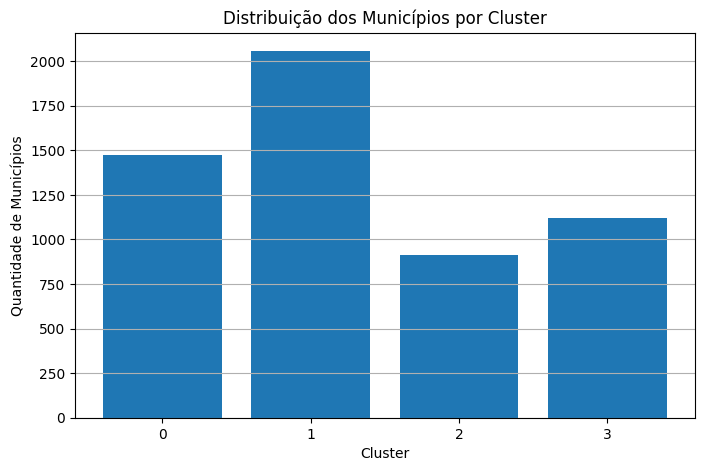

In [7]:
# — Distribuição dos Municípios por Cluster ─────────────────────
# COMO funciona: contabiliza os municípios pertencentes a cada cluster.
# ONDE é usado: avaliação do equilíbrio da segmentação.
# POR QUE esta escolha: verificar a representatividade dos grupos.
# QUANDO rodar: após carregar a base clusterizada.
# O QUE produz: gráfico de barras com a distribuição dos clusters.

import matplotlib.pyplot as plt

distribuicao = (
    df_municipios["cluster_refinado"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    distribuicao.index.astype(str),
    distribuicao.values
)

plt.title(
    "Distribuição dos Municípios por Cluster"
)

plt.xlabel("Cluster")

plt.ylabel(
    "Quantidade de Municípios"
)

plt.grid(axis="y")

plt.show()

## Insight de Negócio — Distribuição dos Clusters

A segmentação refinada apresentou distribuição relativamente equilibrada entre os grupos identificados.

Esse resultado indica que o modelo conseguiu reduzir a influência de municípios extremos e formar segmentos mais representativos da diversidade econômica e demográfica brasileira.

A distribuição equilibrada aumenta a utilidade da segmentação para análises de mercado, expansão comercial e identificação de oportunidades regionais.

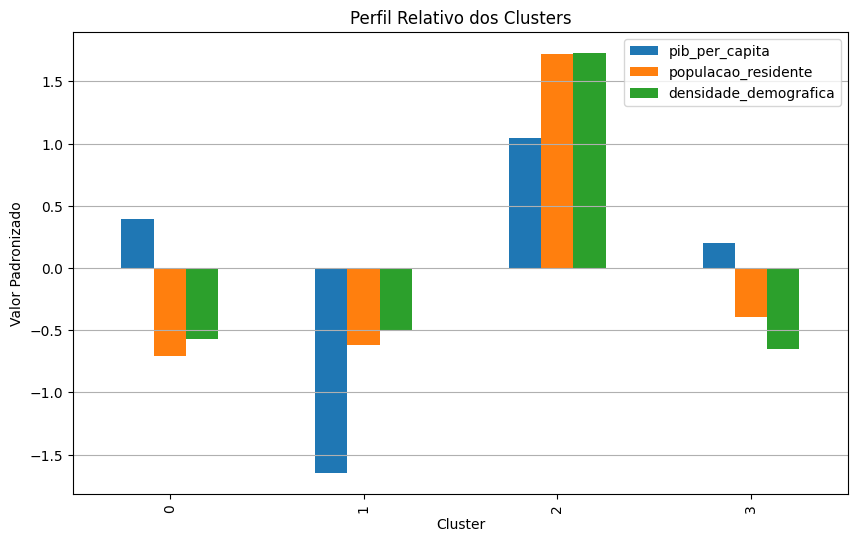

In [9]:
# — Comparação Padronizada dos Clusters ─────────────────────────
# COMO funciona: padroniza os indicadores para comparação visual.
# ONDE é usado: análise dos perfis médios dos clusters.
# POR QUE esta escolha: eliminar problemas de escala entre variáveis.
# QUANDO rodar: após análise da distribuição dos clusters.
# O QUE produz: gráfico comparativo normalizado.

from sklearn.preprocessing import StandardScaler

perfil_clusters = (
    df_municipios
    .groupby("cluster_refinado")
    [
        [
            "pib_per_capita",
            "populacao_residente",
            "densidade_demografica"
        ]
    ]
    .mean()
)

scaler = StandardScaler()

perfil_padronizado = pd.DataFrame(
    scaler.fit_transform(perfil_clusters),
    columns=perfil_clusters.columns,
    index=perfil_clusters.index
)

perfil_padronizado.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Perfil Relativo dos Clusters"
)

plt.ylabel(
    "Valor Padronizado"
)

plt.xlabel(
    "Cluster"
)

plt.grid(axis="y")

plt.show()

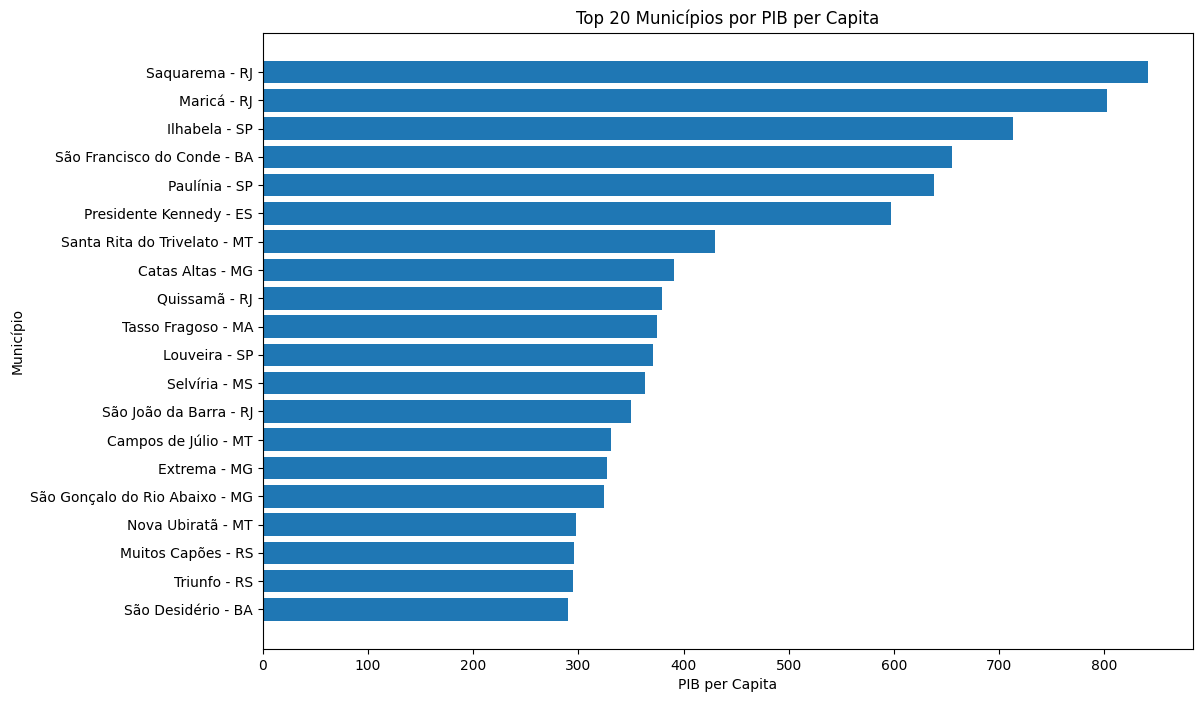

In [10]:
# — Top 20 Municípios por PIB per Capita ────────────────────────
# COMO funciona: seleciona os municípios com maior PIB per capita.
# ONDE é usado: identificação dos mercados economicamente mais relevantes.
# POR QUE esta escolha: destacar municípios com elevada geração de riqueza.
# QUANDO rodar: após a análise dos clusters.
# O QUE produz: ranking visual dos municípios líderes.

import matplotlib.pyplot as plt

top20 = (
    df_municipios
    .sort_values(
        by="pib_per_capita",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,8))

plt.barh(
    top20["municipio"],
    top20["pib_per_capita"]
)

plt.title(
    "Top 20 Municípios por PIB per Capita"
)

plt.xlabel(
    "PIB per Capita"
)

plt.ylabel(
    "Município"
)

plt.gca().invert_yaxis()

plt.show()

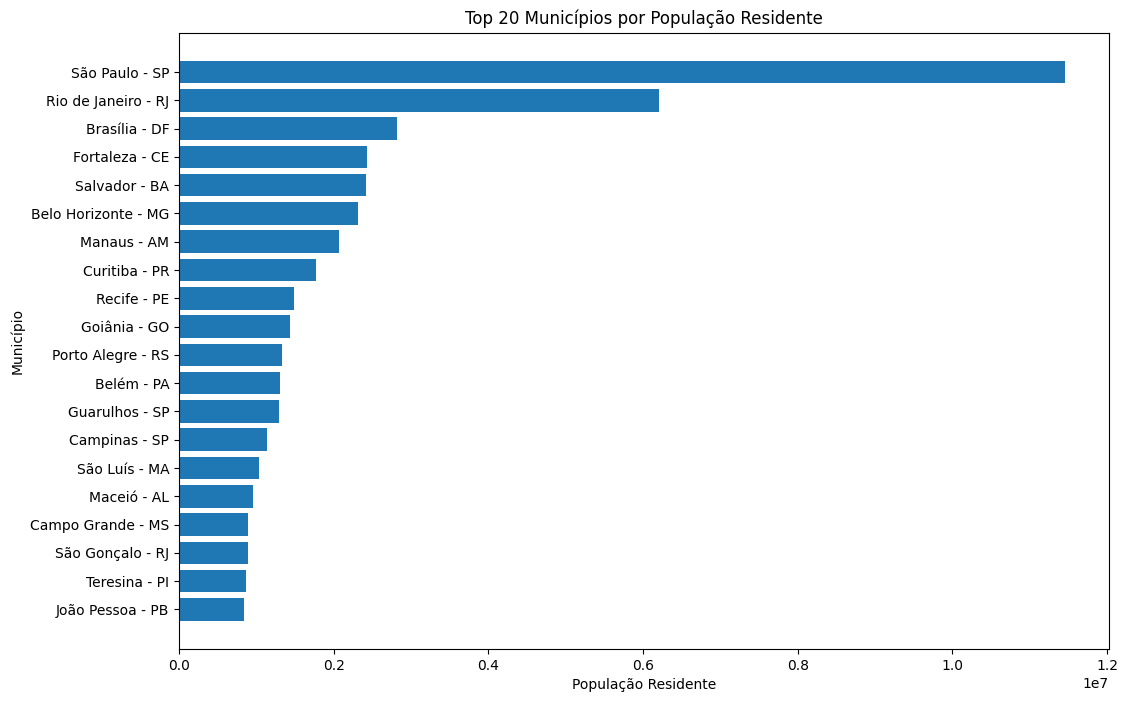

In [11]:
# — Top 20 Mercados por População Residente ─────────────────────
# COMO funciona: identifica os municípios com maior população residente.
# ONDE é usado: análise do tamanho potencial dos mercados consumidores.
# POR QUE esta escolha: população é um dos principais indicadores de escala
# de mercado.
# QUANDO rodar: após a análise dos clusters.
# O QUE produz: ranking visual dos maiores mercados consumidores do país.

import matplotlib.pyplot as plt

top20_pop = (
    df_municipios
    .sort_values(
        by="populacao_residente",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,8))

plt.barh(
    top20_pop["municipio"],
    top20_pop["populacao_residente"]
)

plt.title(
    "Top 20 Municípios por População Residente"
)

plt.xlabel(
    "População Residente"
)

plt.ylabel(
    "Município"
)

plt.gca().invert_yaxis()

plt.show()

<Figure size 1000x600 with 0 Axes>

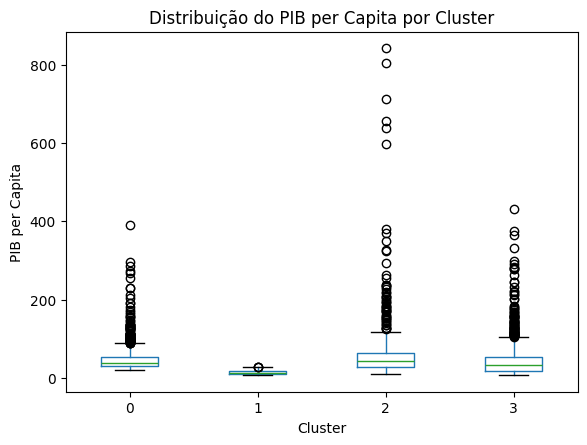

In [12]:
# — Distribuição do PIB per Capita por Cluster ──────────────────
# COMO funciona: exibe a distribuição do PIB per capita dentro de cada cluster.
# ONDE é usado: validação visual da segmentação dos mercados.
# POR QUE esta escolha: identificar diferenças de renda, dispersão e outliers.
# QUANDO rodar: após a geração dos rankings de mercado.
# O QUE produz: boxplot comparando os clusters refinados.

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df_municipios.boxplot(
    column="pib_per_capita",
    by="cluster_refinado",
    grid=False
)

plt.title(
    "Distribuição do PIB per Capita por Cluster"
)

plt.suptitle("")

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "PIB per Capita"
)

plt.show()

# O que os gráficos mostram?

## Os clusters ficaram equilibrados?

Sim.

Depois do refinamento da clusterização, os municípios ficaram distribuídos de forma muito mais equilibrada entre os grupos. Isso é importante porque indica que o modelo deixou de separar apenas casos extremos e passou a identificar padrões mais representativos da realidade brasileira.

Em outras palavras, os clusters passaram a refletir diferentes perfis de mercado, e não apenas diferenças de tamanho econômico.

---

## Como cada cluster se comporta?

Ao comparar PIB per capita, população e densidade demográfica, ficou evidente que os grupos possuem características bastante distintas.

O Cluster 2 concentra municípios mais populosos, mais densos e com maior geração de riqueza, representando os principais centros econômicos do país.

O Cluster 1 apresentou os menores indicadores em praticamente todas as variáveis analisadas, formando um grupo de municípios com menor dinamismo econômico.

Já os Clusters 0 e 3 chamam atenção por possuírem bons níveis de PIB per capita, mas em contextos diferentes. Enquanto o Cluster 0 reúne municípios menores e relativamente eficientes economicamente, o Cluster 3 é formado por municípios extensos, pouco povoados e ligados a atividades como agronegócio, mineração e energia.

---

## Onde está a riqueza?

O ranking de PIB per capita mostrou que os municípios mais ricos do país não são necessariamente os mais conhecidos ou mais populosos.

Muitos dos líderes estão ligados a atividades econômicas específicas, como petróleo, mineração e agronegócio, capazes de gerar grande riqueza mesmo em cidades com poucos habitantes.

Isso mostra que riqueza econômica e tamanho de mercado não são a mesma coisa.

---

## Onde estão os maiores mercados consumidores?

Quando observamos a população residente, aparecem municípios completamente diferentes dos vistos no ranking de PIB per capita.

Isso acontece porque uma cidade pode gerar muita riqueza, mas ter poucos consumidores, enquanto outra pode ter uma população enorme e movimentar grandes volumes de consumo mesmo sem apresentar os maiores níveis de renda.

Por isso, decisões de marketing, expansão comercial e posicionamento de produtos não devem considerar apenas um único indicador.

---

## O que o boxplot revelou?

O boxplot confirmou que os clusters realmente representam grupos diferentes.

O Cluster 2 apresentou os maiores níveis de PIB per capita e também a maior diversidade interna, reunindo alguns dos municípios economicamente mais fortes do Brasil.

Já o Cluster 1 mostrou comportamento mais homogêneo, enquanto os Clusters 0 e 3 apresentaram perfis intermediários com características próprias.

Além disso, a presença de municípios muito acima da média em todos os grupos reforça a enorme diversidade econômica existente entre os municípios brasileiros.

---

## Principal aprendizado

O mesmo nível de riqueza pode aparecer em mercados completamente diferentes.

Alguns municípios concentram população, consumo e atividade econômica ao mesmo tempo. Outros geram riqueza em setores específicos, mas possuem poucos habitantes. Há ainda municípios menores que conseguem apresentar indicadores econômicos muito superiores à média nacional.

Por isso, entender um mercado exige olhar diferentes variáveis em conjunto. Foi justamente essa combinação de indicadores que permitiu identificar perfis distintos de municípios e construir uma segmentação mais próxima da realidade econômica brasileira.
